In [ ]:
import re
import yaml
import numpy as np
import matplotlib.pyplot as plt


def load_yaml(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f) or {}


def parse_char_count_line(line: str):
    s = line.strip()
    if not s:
        return None

    if "\t" in s:
        a, b = s.split("\t", 1)
        a, b = a.strip(), b.strip()
        if re.fullmatch(r"\d+", b):
            return a, int(b)
        if re.fullmatch(r"\d+", a):
            return b, int(a)

    parts = [p for p in re.split(r"[: ,]+", s) if p]
    if len(parts) >= 2:
        if re.fullmatch(r"\d+", parts[1]):
            return parts[0], int(parts[1])
        if re.fullmatch(r"\d+", parts[0]):
            return parts[1], int(parts[0])

    return None


def load_char_count(path: str) -> dict:
    char_count = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parsed = parse_char_count_line(line)
            if parsed is None:
                continue
            ch, cnt = parsed
            char_count[ch] = cnt
    return char_count


def extract_char_confusion(metric_dict: dict) -> dict:
    out = {}
    marker = ".per_char_confusion."
    suffixes = (".tp", ".tn", ".fp", ".fn")

    for k, v in metric_dict.items():
        if not isinstance(k, str) or marker not in k or not k.endswith(suffixes):
            continue

        tail = k.split(marker, 1)[1]
        ch, metric_name = tail.rsplit(".", 1)
        if ch not in out:
            out[ch] = {"tp": 0.0, "tn": 0.0, "fp": 0.0, "fn": 0.0}

        try:
            out[ch][metric_name] = float(v)
        except (TypeError, ValueError):
            out[ch][metric_name] = 0.0

    return out


def make_bins_from_edges(edges, multiline_label=True):
    """
    edges 예: [1, 2, 3, 10, 100]
    결과: [("1~2",1,2), ..., ("100+",100,None)]
    """
    if edges is None or len(edges) < 2:
        raise ValueError("bin_edges must have at least 2 values")

    edges = sorted(set(int(x) for x in edges))
    bins = []
    sep = "~\n" if multiline_label else "~"

    for i in range(len(edges) - 1):
        low, high = edges[i], edges[i + 1]
        bins.append((f"{low}{sep}{high}", low, high))
    bins.append((f"{edges[-1]}+", edges[-1], None))
    return bins


def in_bin(count: int, low: int, high):
    if high is None:
        return count >= low
    return (count >= low) and (count < high)


def aggregate_bin_confusion(char_count: dict, confusion: dict, low: int, high):
    totals = {"tp": 0.0, "tn": 0.0, "fp": 0.0, "fn": 0.0}
    chars_in_bin = []

    for ch, cnt in char_count.items():
        if not in_bin(cnt, low, high):
            continue
        chars_in_bin.append(ch)

        if ch not in confusion:
            continue

        totals["tp"] += confusion[ch].get("tp", 0.0)
        totals["tn"] += confusion[ch].get("tn", 0.0)
        totals["fp"] += confusion[ch].get("fp", 0.0)
        totals["fn"] += confusion[ch].get("fn", 0.0)

    eps = 1e-8
    f1 = (2.0 * totals["tp"]) / (2.0 * totals["tp"] + totals["fp"] + totals["fn"] + eps)
    return totals, f1, chars_in_bin


def summarize_metric_by_bins(metric_path: str, char_count: dict, bins):
    metric = load_yaml(metric_path)
    confusion = extract_char_confusion(metric)

    rows = []
    for label, low, high in bins:
        totals, f1, chars_bin = aggregate_bin_confusion(char_count, confusion, low, high)
        rows.append(
            {
                "label": label,
                "low": low,
                "high": high,
                "num_chars": len(chars_bin),
                "tp": totals["tp"],
                "tn": totals["tn"],
                "fp": totals["fp"],
                "fn": totals["fn"],
                "f1": f1,
            }
        )
    return rows


def print_bin_summary(rows_c, rows_g, name_c="C", name_g="G"):
    print("[Per-bin aggregated confusion]")
    for rc, rg in zip(rows_c, rows_g):
        label = rc["label"]
        print(f"\n{label} (num chars in char_count: {rc['num_chars']})")
        print(
            f"  {name_c} -> tp={rc['tp']:.0f}, tn={rc['tn']:.0f}, fp={rc['fp']:.0f}, fn={rc['fn']:.0f}, f1={rc['f1']:.4f}"
        )
        print(
            f"  {name_g} -> tp={rg['tp']:.0f}, tn={rg['tn']:.0f}, fp={rg['fp']:.0f}, fn={rg['fn']:.0f}, f1={rg['f1']:.4f}"
        )


def plot_bin_f1(rows_c, rows_g, name_c="C", name_g="G"):
    labels = [r["label"] for r in rows_c]
    c_f1 = [r["f1"] for r in rows_c]
    g_f1 = [r["f1"] for r in rows_g]

    x = np.arange(len(labels))
    bar_w = 0.38

    plt.figure(figsize=(12, 6))
    plt.bar(x - bar_w / 2, g_f1, width=bar_w, color="#4C78A8", alpha=0.9, label=f"{name_g} integrated F1")
    plt.bar(x + bar_w / 2, c_f1, width=bar_w, color="#F58518", alpha=0.9, label=f"{name_c} integrated F1")

    plt.xticks(x, labels)
    plt.ylim(0.0, 1.02)
    plt.ylabel("Integrated F1 (from summed TP/FP/FN)")
    plt.xlabel("Character frequency bins")
    plt.title("Integrated per-bin F1 by character frequency")
    plt.grid(axis="y", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_char_bin_analysis(c_path, g_path, char_count_path, bin_edges, name_c="C", name_g="G"):
    bins = make_bins_from_edges(bin_edges, multiline_label=True)
    char_count = load_char_count(char_count_path)

    rows_c = summarize_metric_by_bins(c_path, char_count, bins)
    rows_g = summarize_metric_by_bins(g_path, char_count, bins)

    print_bin_summary(rows_c, rows_g, name_c=name_c, name_g=name_g)
    plot_bin_f1(rows_c, rows_g, name_c=name_c, name_g=name_g)

    return rows_c, rows_g


# ---- Example usage ----
if "c_path" not in globals():
    c_path = "/home/resources/gch/4_work/7_svtr2_smtr_gtc_rctc___q_head___pre_t___e10___warmup_0.5/1_C___id_98/test/dataset_20/epoch_10___id_146/eval_result.yml"
if "g_path" not in globals():
    g_path = "/home/resources/gch/4_work/7_svtr2_smtr_gtc_rctc___q_head___pre_t___e10___warmup_0.5/2_G___id_94/test/dataset_20/epoch_10___id_146/eval_result.yml"

char_count_path = "/home/resources/gch/1_datasets/1_AIHUB/2_split_horizontal_clean_80:10:10/1_train/1_main___id_14/char_count.txt"
bin_edges = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 60, 100, 300, 600, 1000, 3000]

rows_c, rows_g = run_char_bin_analysis(c_path, g_path, char_count_path, bin_edges)

[Per-bin aggregated confusion]

1~
2 (num chars in char_count: 200)
  C -> tp=8, tn=5085310, fp=0, fn=21, f1=0.4324
  G -> tp=22, tn=7028394, fp=9, fn=7, f1=0.7333

2~
3 (num chars in char_count: 97)
  C -> tp=17, tn=6053947, fp=0, fn=11, f1=0.7556
  G -> tp=19, tn=6543771, fp=2, fn=9, f1=0.7755

3~
4 (num chars in char_count: 61)
  C -> tp=26, tn=5085312, fp=0, fn=1, f1=0.9811
  G -> tp=25, tn=5574319, fp=3, fn=2, f1=0.9091

4~
5 (num chars in char_count: 43)
  C -> tp=17, tn=4358841, fp=2, fn=2, f1=0.8947
  G -> tp=18, tn=4120151, fp=1, fn=1, f1=0.9474

5~
6 (num chars in char_count: 26)
  C -> tp=14, tn=2905890, fp=0, fn=4, f1=0.8750
  G -> tp=16, tn=3150699, fp=2, fn=2, f1=0.8889

6~
7 (num chars in char_count: 30)
  C -> tp=16, tn=3874288, fp=3, fn=6, f1=0.7805
  G -> tp=16, tn=3877783, fp=3, fn=6, f1=0.7805

7~
8 (num chars in char_count: 26)
  C -> tp=23, tn=3874055, fp=2, fn=2, f1=0.9200
  G -> tp=24, tn=3393056, fp=1, fn=1, f1=0.9600

8~
9 (num chars in char_count: 23)
  C -> 

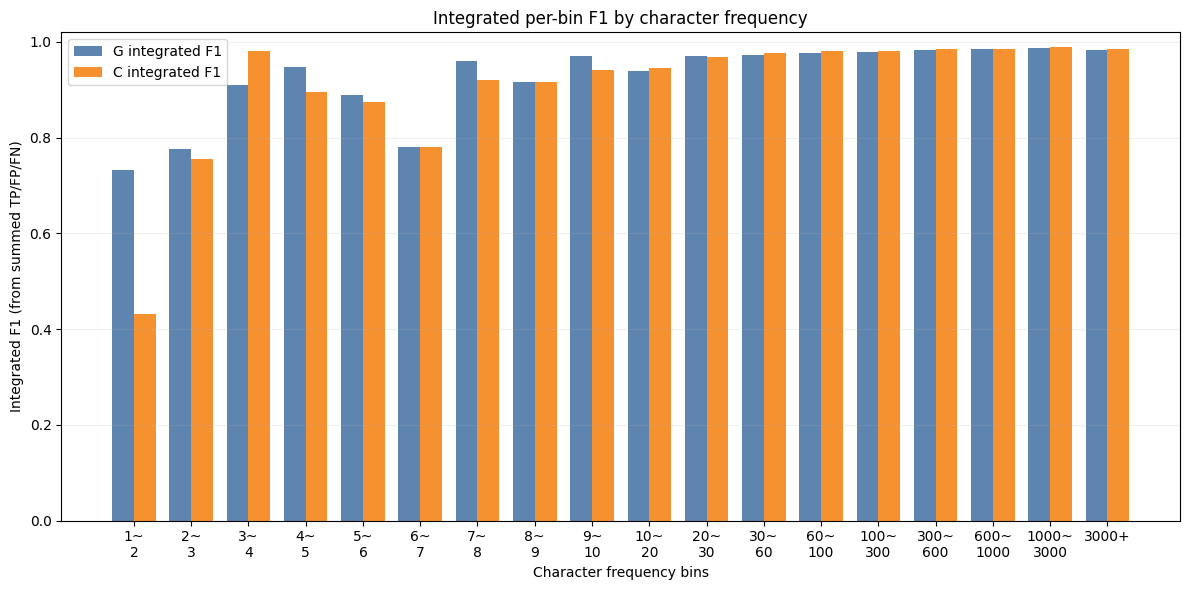

In [1]:
import re
import yaml
import numpy as np
import matplotlib.pyplot as plt

# 기존 셀에 c_path/g_path가 있으면 재사용
if "c_path" not in globals():
    c_path = "/home/resources/gch/4_work/7_svtr2_smtr_gtc_rctc___q_head___pre_t___e10___warmup_0.5/1_C___id_98/test/dataset_20/epoch_10___id_146/eval_result.yml"
if "g_path" not in globals():
    g_path = "/home/resources/gch/4_work/7_svtr2_smtr_gtc_rctc___q_head___pre_t___e10___warmup_0.5/2_G___id_94/test/dataset_20/epoch_10___id_146/eval_result.yml"

char_count_path = "/home/resources/gch/1_datasets/1_AIHUB/2_split_horizontal_clean_80:10:10/1_train/1_main___id_14/char_count.txt"

# 기준점 리스트 (인접한 값 사이를 구간으로 사용)
# 예: [0, 10, 100, 1000, 10000]
# -> [0,10), [10,100), [100,1000), [1000,10000), [10000,+inf)
bin_edges = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 60, 100, 300, 600, 1000, 3000]
# bin_edges = list (range(1, 10)) + list(range(10, 100, 10)) + list(range(100, 10000, 100))


def load_yaml(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f) or {}


def parse_char_count_line(line: str):
    s = line.strip()
    if not s:
        return None

    if "\t" in s:
        a, b = s.split("\t", 1)
        a, b = a.strip(), b.strip()
        if re.fullmatch(r"\d+", b):
            return a, int(b)
        if re.fullmatch(r"\d+", a):
            return b, int(a)

    parts = [p for p in re.split(r"[: ,]+", s) if p]
    if len(parts) >= 2:
        if re.fullmatch(r"\d+", parts[1]):
            return parts[0], int(parts[1])
        if re.fullmatch(r"\d+", parts[0]):
            return parts[1], int(parts[0])

    return None


def load_char_count(path: str):
    char_count = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parsed = parse_char_count_line(line)
            if parsed is None:
                continue
            ch, cnt = parsed
            char_count[ch] = cnt
    return char_count


def extract_char_confusion(metric_dict: dict) -> dict:
    out = {}
    marker = ".per_char_confusion."
    suffixes = (".tp", ".tn", ".fp", ".fn")

    for k, v in metric_dict.items():
        if not isinstance(k, str) or marker not in k or not k.endswith(suffixes):
            continue

        tail = k.split(marker, 1)[1]
        ch, metric_name = tail.rsplit(".", 1)
        if ch not in out:
            out[ch] = {"tp": 0.0, "tn": 0.0, "fp": 0.0, "fn": 0.0}

        try:
            out[ch][metric_name] = float(v)
        except (TypeError, ValueError):
            out[ch][metric_name] = 0.0

    return out


def make_bins_from_edges(edges):
    """
    edges 예: [0, 10, 100, 1000, 10000]
    결과: [("0~10",0,10), ..., ("10000+",10000,None)]
    """
    if edges is None or len(edges) < 2:
        raise ValueError("bin_edges must have at least 2 values")

    edges = sorted(set(int(x) for x in edges))
    bins = []
    for i in range(len(edges) - 1):
        low, high = edges[i], edges[i + 1]
        bins.append((f"{low}~\n{high}", low, high))
    bins.append((f"{edges[-1]}+", edges[-1], None))
    return bins


def in_bin(count: int, low: int, high):
    if high is None:
        return count >= low
    return (count >= low) and (count < high)


def aggregate_bin_confusion(char_count: dict, confusion: dict, low: int, high):
    totals = {"tp": 0.0, "tn": 0.0, "fp": 0.0, "fn": 0.0}
    chars_in_bin = []

    for ch, cnt in char_count.items():
        if not in_bin(cnt, low, high):
            continue
        chars_in_bin.append(ch)

        if ch not in confusion:
            continue

        totals["tp"] += confusion[ch].get("tp", 0.0)
        totals["tn"] += confusion[ch].get("tn", 0.0)
        totals["fp"] += confusion[ch].get("fp", 0.0)
        totals["fn"] += confusion[ch].get("fn", 0.0)

    eps = 1e-8
    f1 = (2.0 * totals["tp"]) / (2.0 * totals["tp"] + totals["fp"] + totals["fn"] + eps)
    return totals, f1, chars_in_bin


c_metric = load_yaml(c_path)
g_metric = load_yaml(g_path)
char_count = load_char_count(char_count_path)

c_conf = extract_char_confusion(c_metric)
g_conf = extract_char_confusion(g_metric)

bins = make_bins_from_edges(bin_edges)
labels = []
c_bin_f1 = []
g_bin_f1 = []

print("[Per-bin aggregated confusion]")
for label, low, high in bins:
    labels.append(label)
    c_tot, c_f1, chars_bin = aggregate_bin_confusion(char_count, c_conf, low, high)
    g_tot, g_f1, _ = aggregate_bin_confusion(char_count, g_conf, low, high)

    c_bin_f1.append(c_f1)
    g_bin_f1.append(g_f1)

    print(f"\n{label} (num chars in char_count: {len(chars_bin)})")
    print(f"  C -> tp={c_tot['tp']:.0f}, tn={c_tot['tn']:.0f}, fp={c_tot['fp']:.0f}, fn={c_tot['fn']:.0f}, f1={c_f1:.4f}")
    print(f"  G -> tp={g_tot['tp']:.0f}, tn={g_tot['tn']:.0f}, fp={g_tot['fp']:.0f}, fn={g_tot['fn']:.0f}, f1={g_f1:.4f}")

x = np.arange(len(labels))
bar_w = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - bar_w / 2, g_bin_f1, width=bar_w, color="#4C78A8", alpha=0.9, label="G integrated F1")
plt.bar(x + bar_w / 2, c_bin_f1, width=bar_w, color="#F58518", alpha=0.9, label="C integrated F1")

plt.xticks(x, labels)
plt.ylim(0.0, 1.02)
plt.ylabel("Integrated F1 (from summed TP/FP/FN)")
plt.xlabel("Character frequency bins")
plt.title("Integrated per-bin F1 by character frequency")
plt.grid(axis="y", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import re
import yaml
import numpy as np
import matplotlib.pyplot as plt




def load_yaml(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f) or {}


def parse_char_count_line(line: str):
    s = line.strip()
    if not s:
        return None

    if "\t" in s:
        a, b = s.split("\t", 1)
        a, b = a.strip(), b.strip()
        if re.fullmatch(r"\d+", b):
            return a, int(b)
        if re.fullmatch(r"\d+", a):
            return b, int(a)

    parts = [p for p in re.split(r"[: ,]+", s) if p]
    if len(parts) >= 2:
        if re.fullmatch(r"\d+", parts[1]):
            return parts[0], int(parts[1])
        if re.fullmatch(r"\d+", parts[0]):
            return parts[1], int(parts[0])

    return None


def load_char_count(path: str):
    char_count = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parsed = parse_char_count_line(line)
            if parsed is None:
                continue
            ch, cnt = parsed
            char_count[ch] = cnt
    return char_count


def extract_char_confusion(metric_dict: dict) -> dict:
    out = {}
    marker = ".per_char_confusion."
    suffixes = (".tp", ".tn", ".fp", ".fn")

    for k, v in metric_dict.items():
        if not isinstance(k, str) or marker not in k or not k.endswith(suffixes):
            continue

        tail = k.split(marker, 1)[1]
        ch, metric_name = tail.rsplit(".", 1)
        if ch not in out:
            out[ch] = {"tp": 0.0, "tn": 0.0, "fp": 0.0, "fn": 0.0}

        try:
            out[ch][metric_name] = float(v)
        except (TypeError, ValueError):
            out[ch][metric_name] = 0.0

    return out


def make_bins_from_edges(edges):
    """
    edges 예: [0, 10, 100, 1000, 10000]
    결과: [("0~10",0,10), ..., ("10000+",10000,None)]
    """
    if edges is None or len(edges) < 2:
        raise ValueError("bin_edges must have at least 2 values")

    edges = sorted(set(int(x) for x in edges))
    bins = []
    for i in range(len(edges) - 1):
        low, high = edges[i], edges[i + 1]
        bins.append((f"{low}~\n{high}", low, high))
    bins.append((f"{edges[-1]}+", edges[-1], None))
    return bins


def in_bin(count: int, low: int, high):
    if high is None:
        return count >= low
    return (count >= low) and (count < high)


def aggregate_bin_confusion(char_count: dict, confusion: dict, low: int, high):
    totals = {"tp": 0.0, "tn": 0.0, "fp": 0.0, "fn": 0.0}
    chars_in_bin = []

    for ch, cnt in char_count.items():
        if not in_bin(cnt, low, high):
            continue
        chars_in_bin.append(ch)

        if ch not in confusion:
            continue

        totals["tp"] += confusion[ch].get("tp", 0.0)
        totals["tn"] += confusion[ch].get("tn", 0.0)
        totals["fp"] += confusion[ch].get("fp", 0.0)
        totals["fn"] += confusion[ch].get("fn", 0.0)

    eps = 1e-8
    f1 = (2.0 * totals["tp"]) / (2.0 * totals["tp"] + totals["fp"] + totals["fn"] + eps)
    return totals, f1, chars_in_bin

def compare_char_f1(c_path:str, g_path:str, char_count_path:str, bin_edges:list[int]):
    c_metric = load_yaml(c_path)
    g_metric = load_yaml(g_path)
    char_count = load_char_count(char_count_path)

    c_conf = extract_char_confusion(c_metric)
    g_conf = extract_char_confusion(g_metric)

    bins = make_bins_from_edges(bin_edges)
    labels = []
    c_bin_f1 = []
    g_bin_f1 = []

    print("[Per-bin aggregated confusion]")
    for label, low, high in bins:
        labels.append(label)
        c_tot, c_f1, chars_bin = aggregate_bin_confusion(char_count, c_conf, low, high)
        g_tot, g_f1, _ = aggregate_bin_confusion(char_count, g_conf, low, high)

        c_bin_f1.append(c_f1)
        g_bin_f1.append(g_f1)

        print(f"\n{label} (num chars in char_count: {len(chars_bin)})")
        print(f"  C -> tp={c_tot['tp']:.0f}, tn={c_tot['tn']:.0f}, fp={c_tot['fp']:.0f}, fn={c_tot['fn']:.0f}, f1={c_f1:.4f}")
        print(f"  G -> tp={g_tot['tp']:.0f}, tn={g_tot['tn']:.0f}, fp={g_tot['fp']:.0f}, fn={g_tot['fn']:.0f}, f1={g_f1:.4f}")

    x = np.arange(len(labels))
    bar_w = 0.38

    plt.figure(figsize=(12, 6))
    plt.bar(x - bar_w / 2, g_bin_f1, width=bar_w, color="#4C78A8", alpha=0.9, label="G integrated F1")
    plt.bar(x + bar_w / 2, c_bin_f1, width=bar_w, color="#F58518", alpha=0.9, label="C integrated F1")

    plt.xticks(x, labels)
    plt.ylim(0.0, 1.02)
    plt.ylabel("Integrated F1 (from summed TP/FP/FN)")
    plt.xlabel("Character frequency bins")
    plt.title("Integrated per-bin F1 by character frequency")
    plt.grid(axis="y", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()


# AIHub Eval

[Per-bin aggregated confusion]

1~
2 (num chars in char_count: 200)
  C -> tp=8, tn=5085310, fp=0, fn=21, f1=0.4324
  G -> tp=22, tn=7028394, fp=9, fn=7, f1=0.7333

2~
3 (num chars in char_count: 97)
  C -> tp=17, tn=6053947, fp=0, fn=11, f1=0.7556
  G -> tp=19, tn=6543771, fp=2, fn=9, f1=0.7755

3~
4 (num chars in char_count: 61)
  C -> tp=26, tn=5085312, fp=0, fn=1, f1=0.9811
  G -> tp=25, tn=5574319, fp=3, fn=2, f1=0.9091

4~
5 (num chars in char_count: 43)
  C -> tp=17, tn=4358841, fp=2, fn=2, f1=0.8947
  G -> tp=18, tn=4120151, fp=1, fn=1, f1=0.9474

5~
6 (num chars in char_count: 26)
  C -> tp=14, tn=2905890, fp=0, fn=4, f1=0.8750
  G -> tp=16, tn=3150699, fp=2, fn=2, f1=0.8889

6~
7 (num chars in char_count: 30)
  C -> tp=16, tn=3874288, fp=3, fn=6, f1=0.7805
  G -> tp=16, tn=3877783, fp=3, fn=6, f1=0.7805

7~
8 (num chars in char_count: 26)
  C -> tp=23, tn=3874055, fp=2, fn=2, f1=0.9200
  G -> tp=24, tn=3393056, fp=1, fn=1, f1=0.9600

8~
9 (num chars in char_count: 23)
  C -> 

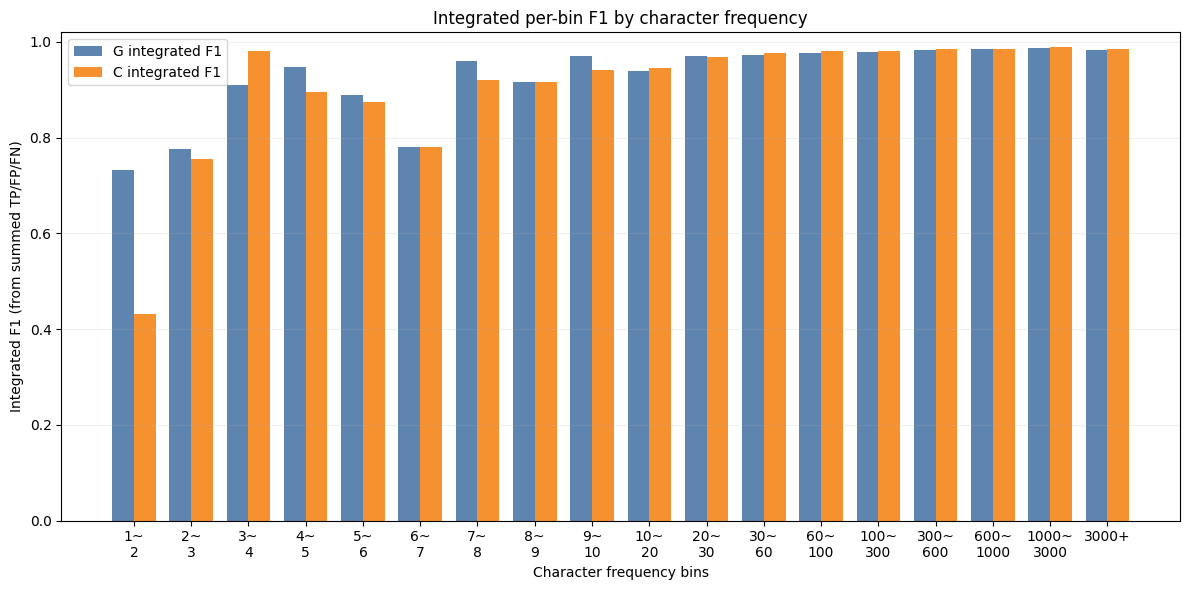

In [7]:
c_path = "/home/resources/gch/4_work/7_svtr2_smtr_gtc_rctc___q_head___pre_t___e10___warmup_0.5/1_C___id_98/test/dataset_20/epoch_10___id_146/eval_result.yml"
g_path = "/home/resources/gch/4_work/7_svtr2_smtr_gtc_rctc___q_head___pre_t___e10___warmup_0.5/2_G___id_94/test/dataset_20/epoch_10___id_146/eval_result.yml"
char_count_path = "/home/resources/gch/1_datasets/1_AIHUB/2_split_horizontal_clean_80:10:10/1_train/1_main___id_14/char_count.txt"

bin_edges = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 60, 100, 300, 600, 1000, 3000]
compare_char_f1(c_path, g_path, char_count_path, bin_edges)

# GIST

[Per-bin aggregated confusion]

1~
2 (num chars in char_count: 200)
  C -> tp=0, tn=114352, fp=1, fn=2, f1=0.0000
  G -> tp=0, tn=267172, fp=5, fn=2, f1=0.0000

2~
3 (num chars in char_count: 97)
  C -> tp=0, tn=76246, fp=1, fn=1, f1=0.0000
  G -> tp=1, tn=229120, fp=5, fn=0, f1=0.2857

3~
4 (num chars in char_count: 61)
  C -> tp=0, tn=0, fp=0, fn=0, f1=0.0000
  G -> tp=0, tn=114560, fp=3, fn=0, f1=0.0000

4~
5 (num chars in char_count: 43)
  C -> tp=1, tn=76246, fp=0, fn=1, f1=0.6667
  G -> tp=1, tn=152611, fp=3, fn=1, f1=0.3333

5~
6 (num chars in char_count: 26)
  C -> tp=3, tn=152490, fp=0, fn=3, f1=0.6667
  G -> tp=6, tn=305222, fp=4, fn=0, f1=0.7500

6~
7 (num chars in char_count: 30)
  C -> tp=1, tn=114369, fp=0, fn=2, f1=0.5000
  G -> tp=2, tn=190765, fp=2, fn=1, f1=0.5714

7~
8 (num chars in char_count: 26)
  C -> tp=3, tn=114368, fp=0, fn=1, f1=0.8571
  G -> tp=3, tn=228917, fp=3, fn=1, f1=0.6000

8~
9 (num chars in char_count: 23)
  C -> tp=1, tn=76246, fp=1, fn=0, f1=0.666

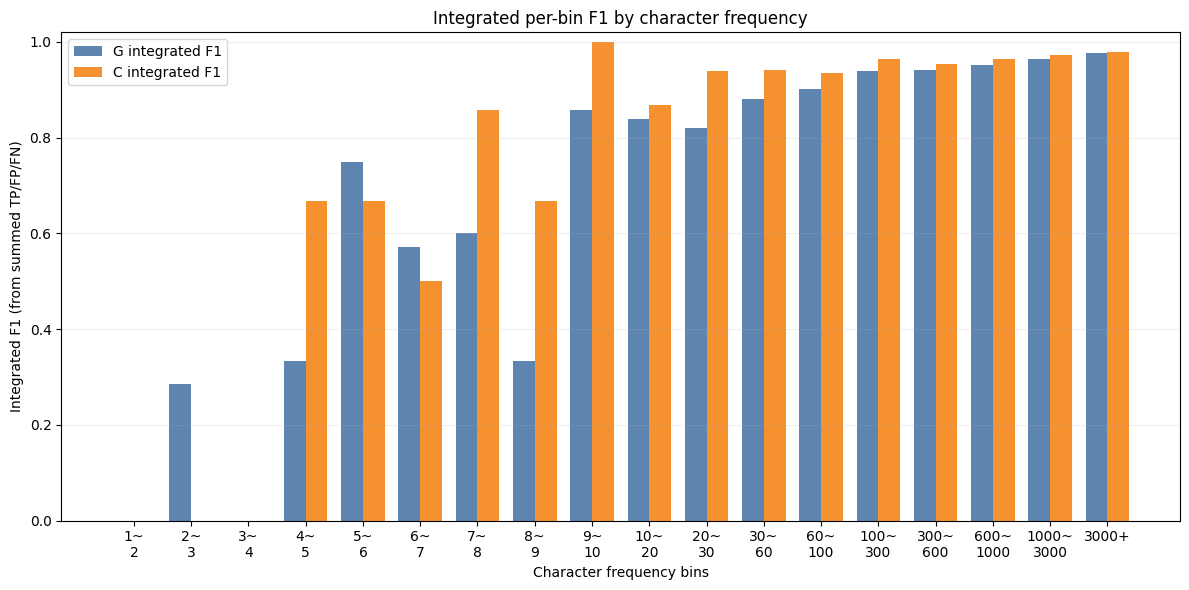

In [8]:

c_path = "/home/resources/gch/4_work/7_svtr2_smtr_gtc_rctc___q_head___pre_t___e10___warmup_0.5/1_C___id_98/test/dataset_39/epoch_10___id_154/eval_result.yml"
g_path = "/home/resources/gch/4_work/7_svtr2_smtr_gtc_rctc___q_head___pre_t___e10___warmup_0.5/2_G___id_94/test/dataset_39/epoch_10___id_154/eval_result.yml"
compare_char_f1(c_path, g_path, char_count_path, bin_edges)



# KAIST

[Per-bin aggregated confusion]

1~
2 (num chars in char_count: 200)
  C -> tp=0, tn=14137, fp=0, fn=1, f1=0.0000
  G -> tp=1, tn=160289, fp=10, fn=0, f1=0.1667

2~
3 (num chars in char_count: 97)
  C -> tp=1, tn=28273, fp=0, fn=2, f1=0.5000
  G -> tp=1, tn=58263, fp=2, fn=2, f1=0.3333

3~
4 (num chars in char_count: 61)
  C -> tp=2, tn=42410, fp=1, fn=1, f1=0.6667
  G -> tp=2, tn=87142, fp=5, fn=1, f1=0.4000

4~
5 (num chars in char_count: 43)
  C -> tp=3, tn=28273, fp=0, fn=0, f1=1.0000
  G -> tp=3, tn=43634, fp=1, fn=0, f1=0.8571

5~
6 (num chars in char_count: 26)
  C -> tp=2, tn=28274, fp=0, fn=0, f1=1.0000
  G -> tp=2, tn=29006, fp=0, fn=0, f1=1.0000

6~
7 (num chars in char_count: 30)
  C -> tp=0, tn=0, fp=0, fn=0, f1=0.0000
  G -> tp=0, tn=0, fp=0, fn=0, f1=0.0000

7~
8 (num chars in char_count: 26)
  C -> tp=2, tn=14135, fp=1, fn=0, f1=0.8000
  G -> tp=2, tn=14500, fp=2, fn=0, f1=0.6667

8~
9 (num chars in char_count: 23)
  C -> tp=0, tn=0, fp=0, fn=0, f1=0.0000
  G -> tp=0, tn

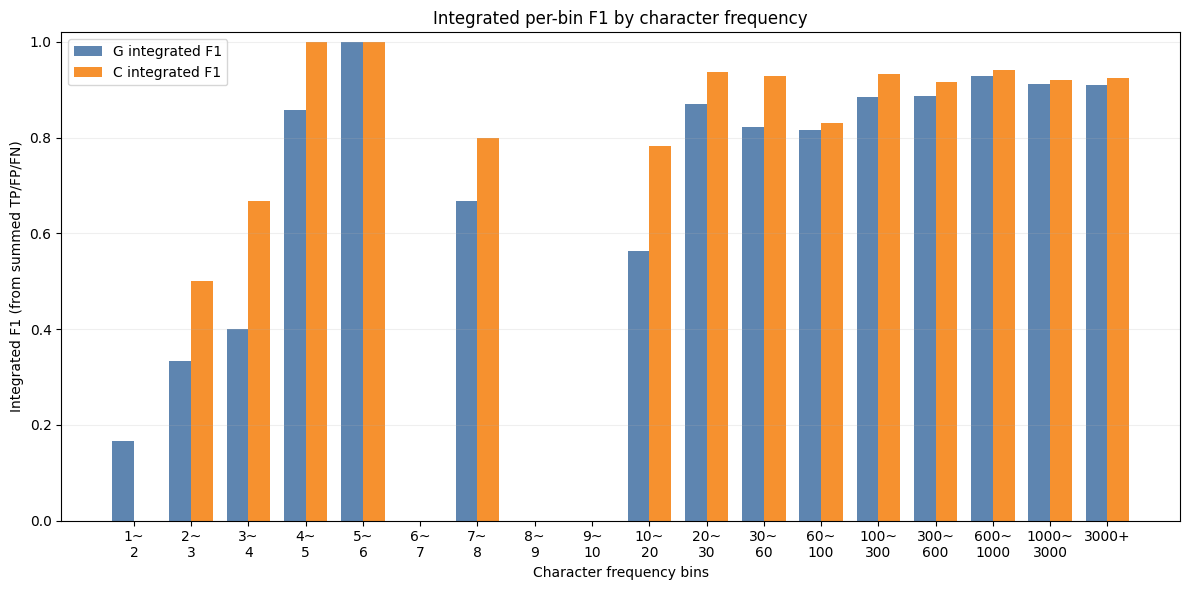

In [5]:
c_path = "/home/resources/gch/4_work/7_svtr2_smtr_gtc_rctc___q_head___pre_t___e10___warmup_0.5/1_C___id_98/test/dataset_45/epoch_10___id_158/eval_result.yml"
g_path = "/home/resources/gch/4_work/7_svtr2_smtr_gtc_rctc___q_head___pre_t___e10___warmup_0.5/2_G___id_94/test/dataset_45/epoch_10___id_158/eval_result.yml"
compare_char_f1(c_path, g_path, char_count_path, bin_edges)
